In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar los datos limpios 
train_df = pd.read_csv('../03_datasets/train_data_prepared.csv')
val_df = pd.read_csv('../03_datasets/val_data_prepared.csv')
test_df = pd.read_csv('../03_datasets/test_data_prepared.csv')

# 2. Separar la "X" (Características) de la "Y" (Target/Precio)
# ¡Eliminamos el precio de compra y el de alquiler para que la IA no haga trampa!
columnas_a_borrar = ['buy_price_log', 'rent_price']

X_train = train_df.drop(columnas_a_borrar, axis=1)
y_train = train_df['buy_price_log']

X_val = val_df.drop(columnas_a_borrar, axis=1)
y_val = val_df['buy_price_log']

X_test = test_df.drop(columnas_a_borrar, axis=1)
y_test = test_df['buy_price_log']

print(f"Forma de X_train (Variables de entrada limpias): {X_train.shape}")


Forma de X_train (Variables de entrada limpias): (11454, 16)


In [8]:
# Como los datos ya vienen perfectamente limpios y escalados por Alfredo 
# en su CSV, ¡no necesitamos (ni debemos) aplicar StandardScaler aquí!
# Pasamos los datos directos para no hacer "doble escalado".

X_train_scaled = X_train
X_val_scaled = X_val
X_test_scaled = X_test

print("¡Datos listos para la Red Neuronal sin el error del doble escalado!")

¡Datos listos para la Red Neuronal sin el error del doble escalado!


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber # <-- Importamos Huber

# 1. Arquitectura 
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),   

    Dense(128, activation='relu'),              
    BatchNormalization(),                       
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1)                                   # Salida lineal para regresión
])

# 2. Compilar con learning rate explícito
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=Huber(), # <-- CAMBIO CLAVE: Huber ignora los precios extremos y da estabilidad
    metrics=['mae']
)

# 3. Callbacks mejorados
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,                      
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(       
    monitor='val_loss',
    factor=0.5,                       
    patience=8,
    min_lr=1e-6,
    verbose=1
)

# 4. Entrenar con más épocas
print("Iniciando el entrenamiento de la Red Neuronal...\n")

fit_params = {
    "validation_data": (X_val, y_val),
    "epochs": 500,
    "batch_size": 32,
    "callbacks": [early_stop, reduce_lr],
    "verbose": 1
}

history = model.fit(
    X_train_scaled, y_train, **fit_params
)


Iniciando el entrenamiento de la Red Neuronal...

Epoch 1/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.4663 - mae: 3.9276 - val_loss: 0.2532 - val_mae: 0.6086 - learning_rate: 0.0010
Epoch 2/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2831 - mae: 1.7197 - val_loss: 0.2089 - val_mae: 0.5197 - learning_rate: 0.0010
Epoch 3/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1434 - mae: 1.5744 - val_loss: 0.2833 - val_mae: 0.6488 - learning_rate: 0.0010
Epoch 4/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - loss: 1.0066 - mae: 1.4326 - val_loss: 0.1368 - val_mae: 0.4106 - learning_rate: 0.0010
Epoch 5/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9044 - mae: 1.3266 - val_loss: 0.1074 - val_mae: 0.3660 - learning_rate: 0.0010
Epoch 6/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - loss: 0.8088 - mae: 1.2211 - val_loss: 0.0828 - val_mae: 0.3143 - learning_rate: 0.0010
Epoch 7/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7303 - mae: 1.1361 - val_

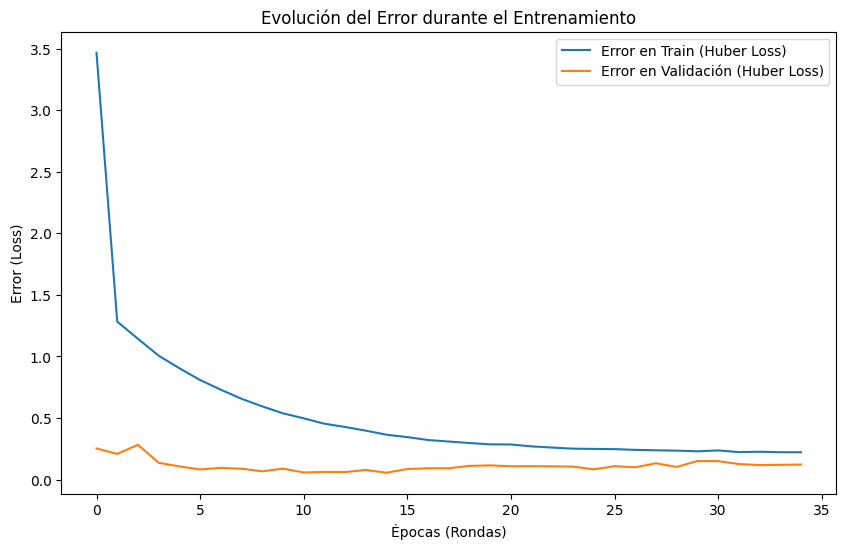

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step

--- RESULTADOS FINALES REALES EN TEST ---
Error Absoluto Medio (MAE): 85,455.12 €
R-Cuadrado (R2): 0.7332


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Ver cómo ha aprendido la red con un gráfico
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Error en Train (Huber Loss)')
plt.plot(history.history['val_loss'], label='Error en Validación (Huber Loss)')
plt.title('Evolución del Error durante el Entrenamiento')
plt.xlabel('Épocas (Rondas)')
plt.ylabel('Error (Loss)')
plt.legend()
plt.show()

# 2. Hacer predicciones sobre los datos de TEST (en escala logarítmica)
test_predictions_log = model.predict(X_test_scaled)

# --- EL ESCUDO MATEMÁTICO (Clipping) ---
# Limitamos las predicciones logarítmicas a un máximo de 15 para evitar 
# que la exponencial explote (np.expm1(15) son unos 3.2 millones de euros).
safe_test_predictions_log = np.clip(test_predictions_log, a_min=0, a_max=15)
# ---------------------------------------

# 3. Convertir los logaritmos a EUROS reales de forma segura
test_predictions_euros = np.expm1(safe_test_predictions_log)

# Aseguramos que y_test se maneje bien si es una serie de Pandas
y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
y_test_euros = np.expm1(y_test_array)

# 4. Calcular métricas finales 
mae = mean_absolute_error(y_test_euros, test_predictions_euros)
r2 = r2_score(y_test_euros, test_predictions_euros)

print("\n--- RESULTADOS FINALES REALES EN TEST ---")
print(f"Error Absoluto Medio (MAE): {mae:,.2f} €")
print(f"R-Cuadrado (R2): {r2:.4f}")

In [11]:
import joblib

# 1. Guardar el modelo de la Red Neuronal (El "Cerebro")
model.save('../models/modelo_compra_definitivo.keras')
print("✅ Modelo de Red Neuronal guardado como 'modelo_compra_definitivo.keras'")


print("\n¡Todo empaquetado y listo!")


✅ Modelo de Red Neuronal guardado como 'modelo_compra_definitivo.keras'

¡Todo empaquetado y listo!


In [12]:
import mlflow
import mlflow
import mlflow.keras
from pathlib import Path

# MLflow crea el archivo mlflow.db solo si no existe
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# 1. Ajuste de ruta de mlruns la ubicación de la raíz del directorio y configuramos experimento
BASE_DIR = Path().resolve().parent  # sube un nivel desde 04_dl_notebooks/ a la raíz
mlflow.set_tracking_uri(f"file://{BASE_DIR}/mlruns")
mlflow.set_experiment(experiment_name="Madrid_Real_Estate_Predictor")

# 2. PERO le ponemos un nombre distinto a esta prueba (para saber que es alquiler)
with mlflow.start_run(run_name="buy_DL"):

    # A. Registramos los parámetros
    mlflow.log_param("epochs", fit_params["epochs"])
    mlflow.log_param("batch_size", fit_params["batch_size"])

    # B. Registramos métricas
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("MAE", mae)

    # C. Guardamos el modelo con la nueva API de MLflow 3.x
    mlflow.keras.log_model(
        model,
        name="buy_model_DL",                        # ← artifact_path → name
        registered_model_name="buy_model"        # ← lo registra directamente en el Registry
    )

print("✅ ¡Modelo de COMPRAS registrado en MLflow con éxito!")

2026/04/03 22:08:47 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/04/03 22:08:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ ¡Modelo de COMPRAS registrado en MLflow con éxito!


Successfully registered model 'buy_model'.
Created version '1' of model 'buy_model'.
